# Lecture 10 — Radiative Equilibrium & the Temperature Correction

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- **Measure** the radiative flux as a function of depth in the grey starting atmosphere and see directly that it is *not* constant — so the grey model violates **radiative equilibrium** and its temperature must be corrected.
- Build the **Rosseland mean opacity** $\kappa_{\rm Ross}$ — a *harmonic*, flux-weighted average over frequency — and the real **Rosseland optical-depth scale** $\tau_{\rm Ross}$ that replaces the grey-start placeholder.
- Compute the per-frequency Eddington flux $H_\nu$ and the moment $(J_\nu-S_\nu)$ with the **JOSH** solver from Lecture 8, and accumulate the four depth integrals the correction needs.
- Assemble the ATLAS temperature correction $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ from its three physically distinct pieces — the **Avrett–Krook** flux-constancy term, the **local-$\Lambda$** surface term, and the **surface-boundary** term — and explain what each one fixes.
- Re-integrate hydrostatic equilibrium for the density correction $\Delta\rho x$, take **one converging step**, and reproduce the production code's corrected temperature to **machine precision** and corrected column mass to the float32 floor.

## Introduction: the half of the atmosphere we still owe

Lecture 9 built the **hydrostatic** half of a model atmosphere: from $T_{\rm eff}$ and $\log g$ it produced a run of temperature, pressure, and column mass that balances the weight of the overlying gas exactly. But it built that structure on two placeholders. The temperature came from the **grey/Hopf law**, which assumes the opacity is the same at every wavelength; and the opacity itself was the crude cold-start value $\kappa\equiv1$. Neither is true of a real star, where the opacity swings over orders of magnitude from one wavelength to the next, and the temperature that the grey law predicts is *not* the temperature that conserves energy.

The missing constraint is **radiative equilibrium**. In the photosphere of a star like the Sun, essentially all the energy flows outward as radiation, and none is created or destroyed locally: nuclear burning is far below, and (with convection switched off, as we keep it here for a clean first reproduction) there is no other channel. Energy conservation then demands that the **radiative flux be the same at every depth** — whatever flux crosses one layer must cross the next. Equivalently, the frequency-integrated flux must equal $\sigma T_{\rm eff}^4$ everywhere, and its divergence must vanish.

The grey atmosphere does not satisfy this. We will *measure* its flux layer by layer and watch it drift with depth — proof that the grey temperature is wrong. ATLAS fixes it with a **temperature correction**: at each depth it computes how far the flux is off, works out which way and by how much the temperature must move to push the flux back toward constancy, and applies that shift. Iterating the correction (recomputing opacities and fluxes on the new temperature, correcting again) drives the model to radiative equilibrium. This lecture builds **one step** of that correction engine — Kurucz's `TCORR` — and benchmarks it to the bit. It reuses two engines we have already built from scratch: the **JOSH** moment solver (Lecture 8) for the per-frequency flux, and the **continuum opacity** (Lecture 3), which we take as a given input so we can spend our effort on the genuinely new physics: the Rosseland mean and the correction itself.

## Setup and the reference

We import only NumPy and Matplotlib. The benchmark target is `reference/tcorr_ref.npz`, produced once by the production code on the solar parameters ($T_{\rm eff}=5770$ K, $\log g=4.44$) in a deliberately clean configuration: **one** ATLAS iteration, **continuum opacity only** (no line blanketing — so no multi-gigabyte line lists are needed), **convection off**, and **serial** execution so the result is bit-reproducible. The file ships:

- the **grey starting model** (`T_in`, `rhox_in`, `p_in`) — the seed from Lecture 9;
- the per-frequency **continuum opacity** on ATLAS's 30000-point frequency grid (`freq_hz`, `rco` quadrature weights, absorption `acont`, scattering `sigmac`, source `scont`) — the Lecture-3 engine's output, treated here as a *given input*;
- the **JOSH tables** (`josh_coefh`) plus the shared `josh_tables.npz` from Lecture 8;
- the reference **accumulators and corrected model** we check against.

We mute the float32 continuum arrays' size by storing them as `float32` (JOSH casts its iterate to float32 internally anyway, so nothing is lost).

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

REF = np.load(pathlib.Path("..") / "reference" / "tcorr_ref.npz")
JT  = np.load(pathlib.Path("..") / "reference" / "josh_tables.npz")   # Lecture 8 tables

TEFF = float(REF["teff"]); LOGG = float(np.log10(float(REF["gravity_cgs"])))
GRAV = float(REF["gravity_cgs"])
print(f"target: temperature correction for Teff = {TEFF:.0f} K, log g = {LOGG:.2f}")
print(f"reference arrays: {len(REF.files)} total")
print(f"  continuum grid: {REF['freq_hz'].size} frequencies x {REF['T_in'].size} layers")

target: temperature correction for Teff = 5770 K, log g = 4.44
reference arrays: 36 total
  continuum grid: 30000 frequencies x 80 layers


### Constants and the depth grid

We use exactly the constants ATLAS uses (the last digits matter for a bit-level match): the Stefan–Boltzmann constant $\sigma$, Planck's $h$, Boltzmann's $k$, and the speed of light expressed in nm/s so that frequency follows from wavelength as $\nu = c/\lambda$. The grey starting model has $N=80$ layers. We pull out the starting temperature `T`, column mass `rhox`, and gas pressure `p_in`, and form the combination $h\nu/(kT)$ at every layer — call it `hkt` — which appears throughout the Planck-function and opacity bookkeeping.

One number sets the whole game: the **target flux**. The Eddington flux that must emerge from a star of effective temperature $T_{\rm eff}$ is $H = \sigma T_{\rm eff}^4/(4\pi)$. (ATLAS works with the Eddington flux $H$, the first moment of the intensity; the physical surface flux is $\mathcal F = 4\pi H = \sigma T_{\rm eff}^4$, the familiar Stefan–Boltzmann law.) Radiative equilibrium is the statement that the depth-dependent flux $H(\tau)$ equals this constant $H$ at every layer.

In [2]:
SIGMA  = 5.6697e-5     # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
PLANCK = 6.6256e-27    # Planck constant h [erg s]
KBOLTZ = 1.38054e-16   # Boltzmann constant k [erg/K]

T    = REF["T_in"].astype(np.float64)      # grey starting temperature [K], 80 layers
rhox = REF["rhox_in"].astype(np.float64)   # column mass RHOX [g/cm^2]
p_in = REF["p_in"].astype(np.float64)      # gas pressure [dyn/cm^2]
n = T.size

hkt = PLANCK / np.maximum(T * KBOLTZ, 1e-300)   # h/(kT) per layer (note: NOT including nu yet)

# the target: Eddington flux H = sigma Teff^4 / (4 pi).  ATLAS writes 4 pi = 12.5664 explicitly.
flux = SIGMA / 12.5664 * TEFF**4
print(f"target Eddington flux  H = sigma Teff^4 / (4 pi) = {flux:.4e} erg cm^-2 s^-1 sr^-1")
print(f"  (physical surface flux F = 4 pi H = sigma Teff^4 = {SIGMA*TEFF**4:.4e} erg cm^-2 s^-1)")

target Eddington flux  H = sigma Teff^4 / (4 pi) = 5.0009e+09 erg cm^-2 s^-1 sr^-1
  (physical surface flux F = 4 pi H = sigma Teff^4 = 6.2844e+10 erg cm^-2 s^-1)


## The numerical toolbox (Lecture 8)

Everything below — the optical-depth integrals, the moment derivatives, the remap onto JOSH's fixed grid — is built from the same four Fortran kernels Lecture 8 introduced, so we reproduce them compactly here rather than re-deriving them. `parcoe` fits a smoothly-blended parabola through each triple of points; `integ` integrates a tabulated function using each interval's parabola (this is how every optical depth and every flux integral is taken); `deriv` is the cubic-tangent derivative that ATLAS uses for $dH/d\tau$ and friends; and `map1` is the piecewise-quadratic interpolation that moves a quantity from one depth grid to another. We will lean on all four. (If any line here is unfamiliar, Lecture 8 walks through it; the point of this lecture is what we *do* with them.)

In [3]:
def parcoe(f, x):
    """Smoothly-blended parabolic coefficients a,b,c so f ~ a + b x + c x^2 (Fortran PARCOE)."""
    nn = f.size; a = np.zeros(nn); b = np.zeros(nn); c = np.zeros(nn)
    if nn == 1: a[0] = f[0]; return a, b, c
    b[0] = (f[1]-f[0])/(x[1]-x[0]); a[0] = f[0]-x[0]*b[0]
    n1 = nn-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    if nn == 2: return a, b, c
    for j in range(1, n1):
        j1 = j-1; d = (f[j]-f[j1])/(x[j]-x[j1])
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]
    if nn > 3: c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]
    for j in range(1, n1):
        if c[j] == 0.0: continue
        j1 = min(j+1, nn-1); den = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/den if den > 0 else 0.0
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]
    return a, b, c

def integ(x, f, start):
    """Cumulative integral of f dx (each interval's parabola), seeded at start (Fortran INTEG)."""
    nn = f.size; out = np.zeros(nn)
    if nn == 0: return out
    a, b, c = parcoe(f, x); out[0] = start
    for i in range(nn-1):
        dx = x[i+1]-x[i]
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        out[i+1] = out[i] + term*dx
    return out

def deriv(x, f):
    """Cubic-tangent derivative df/dx (Fortran DERIV)."""
    nn = f.size; d = np.zeros(nn)
    if nn < 2: return d
    d[0] = (f[1]-f[0])/(x[1]-x[0]); d[-1] = (f[-1]-f[-2])/(x[-1]-x[-2])
    if nn == 2: return d
    s = abs(x[1]-x[0])/(x[1]-x[0]) if x[1] != x[0] else 1.0
    for j in range(1, nn-1):
        scale = max(abs(f[j-1]), abs(f[j]), abs(f[j+1]))
        scale = scale/abs(x[j]) if x[j] != 0.0 else scale
        if scale == 0.0: scale = 1.0
        d1 = (f[j+1]-f[j])/(x[j+1]-x[j])/scale; d0 = (f[j]-f[j-1])/(x[j]-x[j-1])/scale
        t1 = d1/(s*np.sqrt(1.0+d1*d1)+1.0); t0 = d0/(s*np.sqrt(1.0+d0*d0)+1.0)
        d[j] = (t1+t0)/(1.0-t1*t0)*scale
    return d

In [4]:
def map1(xold, fold, xnew):
    """Piecewise-quadratic remap of fold(xold) onto xnew (Fortran MAP1).  Returns (fnew, ll-1)."""
    nold, nnew = xold.size, xnew.size
    fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0: return fnew, 0
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold
    l = 2; ll = 0; cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0
    for k in range(1, nnew+1):
        xk = xnew[k-1]
        while True:
            if xk < xo[l]:
                if l == ll: break
                if l == 2 or l == 3:
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:
                    l2 = l-2; d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1]+xo[l2])*cbac; abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                else:
                    cbac, bbac, abac = cfor, bfor, afor
                if l >= nold: c, b, a, ll = cbac, bbac, abac, l; break
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l]+xo[l1])*cfor; afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0.0 else 0.0
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1
            if l > nold:
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk
    return fnew, max(ll-1, 0)

def map1_scalar(xold, fold, xv):
    out, _ = map1(np.asarray(xold), np.asarray(fold), np.asarray([xv])); return float(out[0])

## JOSH, for the full depth profile (Lecture 8)

Lecture 8 used JOSH to produce one number per wavelength — the emergent surface flux. The temperature correction needs **more**: at every depth and every frequency it needs the Eddington flux $H_\nu(\tau)$ and the moment $(J_\nu - S_\nu)(\tau)$, the difference between the mean intensity and the source function. So here we run the same JOSH algorithm but read out the *depth profiles*, not just the surface value.

The mechanics are exactly Lecture 8's. For a given frequency we form the total extinction $\kappa_\nu$ (continuum absorption + scattering), the scattering fraction $\alpha_\nu = \sigma_\nu/\kappa_\nu$, the thermal-plus-scattering source $\bar S_\nu$, and the monochromatic optical depth $\tau_\nu=\int\kappa_\nu\,d(\rho x)$. We map the source onto JOSH's fixed 51-point $\tau$-grid, run the **float32** $\Lambda$-iteration that solves the scattering problem on that grid (the one place the whole pipeline drops to single precision — Lecture 8 explains why, and it is the reason our final benchmark has a float32 floor), then map the moments $J_\nu - S_\nu$ and $H_\nu$ back onto the physical layers. For this solar continuum the surface optical depth is always thin enough that JOSH solves the outer layers directly on the physical grid (its "label-401" branch) — we reproduce that branch faithfully. The function returns $\tau_\nu$, $H_\nu$, $(J_\nu - S_\nu)$, $\kappa_\nu$, and $\alpha_\nu$ at every layer — the five profiles the correction consumes.

In [5]:
XTAU  = JT["xtau"].astype(np.float64)        # JOSH fixed optical-depth grid (51 points)
COEFJ = JT["coefj"].astype(np.float64)       # J-moment operator (51x51), from Lecture 8
COEFH = REF["josh_coefh"].astype(np.float64) # H-moment operator (51x51); shipped here (L8 omits it)
NX = XTAU.size
COEFJ_DIAG = np.diag(COEFJ).astype(np.float32)
ITER_TOL = 1.0e-5

def josh_profiles(acont, scont, sigmac, rhox, bnu):
    """JOSH depth profiles for one continuum frequency (ifscat=1, line opacity off).
    Returns taunu, H_nu, (J_nu - S_nu), kappa_nu (=abtot), alpha_nu, all at every layer."""
    abtot = np.maximum(acont + sigmac, 1e-300)          # total extinction kappa_nu
    alpha = sigmac / abtot                               # scattering fraction
    den   = acont                                        # (no line absorption in continuum-only)
    snubar = bnu.copy()
    np.divide(acont*scont, den, out=snubar, where=den > 0.0)   # thermal+scattering source Sbar_nu
    taunu = integ(rhox, abtot, abtot[0]*rhox[0])         # monochromatic optical depth
    snu = np.zeros(n); hnu = np.zeros(n); jnu = np.zeros(n); jmins = np.zeros(n)
    xs = np.zeros(NX, dtype=np.float32)

    # --- map source onto the JOSH grid and run the float32 Lambda-iteration ---
    xsbar8, maxj = map1(taunu, snubar, XTAU)
    xalpha8, maxj = map1(taunu, alpha, XTAU)
    xalpha8 = np.maximum(xalpha8.astype(np.float32), np.float32(0.0))
    xsbar8  = np.maximum(xsbar8.astype(np.float32),  np.float32(1.0e-38))
    mask = XTAU < taunu[0]
    if np.any(mask):
        xsbar8[mask] = max(snubar[0], 1.0e-38); xalpha8[mask] = max(alpha[0], 0.0)
    xs[:] = xsbar8
    diag = np.float32(1.0) - xalpha8*COEFJ_DIAG
    xsbar_mod = (np.float32(1.0) - xalpha8)*xsbar8
    for _ in range(NX):                                  # backward Gauss-Seidel sweep, REAL*4
        iferr = 0
        for kk in range(NX):
            k = NX-1-kk
            dot = np.float32(np.dot(COEFJ[k, :].astype(np.float32), xs))
            num = np.float32(dot*xalpha8[k] + xsbar_mod[k] - xs[k])
            dd = np.float32(diag[k])
            if abs(float(dd)) < 1.0e-37: dd = np.float32(1.0e-37 if float(dd) >= 0.0 else -1.0e-37)
            delxs = np.float32(num/dd)
            xb = np.float32(xs[k])
            if abs(float(xb)) < 1.0e-37: xb = np.float32(1.0e-37 if float(xb) >= 0.0 else -1.0e-37)
            if np.float32(abs(float(delxs/xb))) > np.float32(ITER_TOL): iferr = 1
            xs[k] = np.float32(max(float(np.float32(xs[k] + delxs)), 1.0e-37))
        if iferr == 0: break
    snu_head, _ = map1(XTAU, xs.astype(np.float64), taunu[:maxj]); snu[:maxj] = snu_head

    # --- solve the outer layers on the physical TAUNU grid (JOSH "label-401" branch) ---
    maxj1 = maxj+1 if maxj != 1 else 1
    snu[maxj1-1:] = snubar[maxj1-1:]
    m0 = max(maxj-1, 1) - 1; nmj0 = maxj-1
    for _ in range(NX):
        error = 0.0; ifneg = 0
        if np.any(snu[m0:] <= 0.0): ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]
        hnu[m0:] = deriv(taunu[m0:], snu[m0:]) / 3.0
        if np.any(hnu[m0:] <= 0.0):
            ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]
            hnu[m0:] = deriv(taunu[m0:], snu[m0:]) / 3.0
        jmins[nmj0:] = deriv(taunu[nmj0:], hnu[nmj0:])
        for j in range(maxj1-1, n):
            if ifneg == 1: jmins[j] = 0.0
            jnu[j] = jmins[j] + snu[j]
            snew = (1.0-alpha[j])*snubar[j] + alpha[j]*jnu[j]
            error += abs(snew - snu[j]) / max(abs(snew), 1e-300); snu[j] = snew
        if error < ITER_TOL: break

    # --- deeper layers: moments from the grid solution, mapped back ---
    xjs = (-xs + COEFJ.astype(np.float32) @ xs).astype(np.float64)   # (J - S) on the JOSH grid
    xh  = (COEFH @ xs).astype(np.float64)                            # H on the JOSH grid
    jmins[:maxj], _ = map1(XTAU, xjs, taunu[:maxj])
    hnu[:maxj], _   = map1(XTAU, xh,  taunu[:maxj])
    return taunu, hnu, jmins, abtot, alpha

## Sweeping the spectrum: the Rosseland mean and the flux integrals

We now sweep all 30000 continuum frequencies. At each one we build the Planck function $B_\nu(T)$ and the stimulated-emission factor, run JOSH for the depth profiles, and accumulate **five** depth integrals over frequency. Four of them feed the temperature correction; the fifth is the Rosseland mean.

**The Rosseland mean opacity** is the single most important new quantity. To compress a wildly wavelength-dependent opacity into one number per layer for the optical-depth scale, ATLAS uses the *Rosseland mean* — a **harmonic** average of $\kappa_\nu$ weighted by $\partial B_\nu/\partial T$:

$$
\frac{1}{\kappa_{\rm Ross}} = \frac{\displaystyle\int_0^\infty \frac{1}{\kappa_\nu}\,\frac{\partial B_\nu}{\partial T}\,d\nu}{\displaystyle\int_0^\infty \frac{\partial B_\nu}{\partial T}\,d\nu},
\qquad
\int_0^\infty\frac{\partial B_\nu}{\partial T}\,d\nu = \frac{4\sigma}{\pi}T^3 .
$$

The harmonic (reciprocal) weighting is not a convention — it is what falls out of the diffusion limit deep in the star, where the flux is set by *how easily* radiation leaks through, so the *transparent* windows dominate. A simple average would be swamped by the opaque lines; the harmonic mean correctly lets the low-opacity windows carry the flux. We accumulate the denominator integrand $\frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}$ frequency by frequency (note the $1/\kappa_\nu$), then finalize $\kappa_{\rm Ross} = \frac{4\sigma}{\pi}T^3 / (\text{accumulator})$. The frequency integral is done with the quadrature weights `rco` that ship with the grid (the spacing-aware $d\nu$).

In [6]:
freq   = REF["freq_hz"].astype(np.float64)   # 30000 continuum frequencies [Hz]
rco    = REF["rco"].astype(np.float64)       # frequency quadrature weights (d_nu)
acont  = REF["acont"].astype(np.float64)     # continuum absorption [per layer, per freq] (Lecture 3)
sigmac = REF["sigmac"].astype(np.float64)    # continuum scattering
scont  = REF["scont"].astype(np.float64)     # continuum source function
nf = freq.size

# five accumulators, all functions of depth:
ross_acc = np.zeros(n)   # Rosseland denominator: int (1/kappa) dB/dT d_nu
flxrad   = np.zeros(n)   # int H_nu d_nu        -> the radiative flux at each depth
rjmins   = np.zeros(n)   # int kappa (J-S) d_nu -> the net radiative heating
rdabh    = np.zeros(n)   # int (d kappa/d rhox)/kappa * H_nu d_nu  (opacity-gradient term)
rdiagj   = np.zeros(n)   # diagonal of the Lambda operator (how T responds to its own change)

print(f"sweeping {nf} continuum frequencies x {n} layers ... (this is the bulk of the work)")

sweeping 30000 continuum frequencies x 80 layers ... (this is the bulk of the work)


### What the four correction integrals mean

Before we run the loop, here is what each correction integral is for — the physics is easier to follow now than buried in code.

- **`flxrad` $=\int H_\nu\,d\nu$** is simply the **total radiative flux** at each depth. Radiative equilibrium says this should equal the constant target $H$; the whole correction exists to make it so.
- **`rjmins` $=\int \kappa_\nu (J_\nu - S_\nu)\,d\nu$** is the **net radiative heating rate**. Where the gas absorbs more than it emits ($J_\nu>S_\nu$, mean intensity exceeds source), it is being heated; the integral measures that imbalance and is the surface diagnostic for the local correction.
- **`rdabh`** carries the **opacity gradient** $\frac{d\kappa_\nu/d(\rho x)}{\kappa_\nu}$ weighted by the flux: it tells the flux-correction term how the optical-depth scale itself shifts when the structure moves.
- **`rdiagj`** is the **diagonal of the $\Lambda$ operator** — how strongly the radiation field at a layer responds to a change in that same layer's source function. It is built from the third exponential integral $E_3$ of the local optical-depth step, and it is the denominator of the local-$\Lambda$ correction below (it converts a flux error into the temperature change that would cancel it).

We need one special function, $E_3$. The exponential integral $E_3(\tau)=\int_1^\infty t^{-3}e^{-\tau t}\,dt$ measures how much of a layer's emission escapes through an overlying slab of optical thickness $\tau$. ATLAS evaluates it with the same rational-polynomial approximation Kurucz used; we reproduce it (with the $E_3 = (e^{-x}-x E_2)$ recurrence applied twice from $E_1$).

In [7]:
def expi3(x):
    """Third exponential integral E_3(x) via Kurucz's rational approximation (Fortran EXPI(3,x))."""
    a = (-44178.5471728217, 57721.7247139444, 9938.31388962037, 1842.11088668, 101.093806161906, 5.03416184097568)
    b = (76537.3323337614, 32597.1881290275, 6106.10794245759, 635.419418378382, 37.2298352833327)
    c = (4.65627107975096e-7, 0.999979577051595, 9.04161556946329, 24.3784088791317, 23.0192559391333, 6.90522522784444, 0.430967839469389)
    dd = (10.0411643829054, 32.4264210695138, 41.2807841891424, 20.4494785013794, 3.31909213593302, 0.103400130404874)
    e = (-0.999999999998447, -26.6271060431811, -241.055827097015, -895.927957772937, -1298.85688746484, -545.374158883133, -5.66575206533869)
    fc = (28.6271060422192, 292.310039388533, 1332.78537748257, 2777.61949509163, 2404.01713225909, 631.6574832808)
    if x <= 0.0:
        ex1 = 0.0
    else:
        ex = np.exp(-x)
        if x > 4.0:
            ex1 = (ex + ex*(e[0]+(e[1]+(e[2]+(e[3]+(e[4]+(e[5]+e[6]/x)/x)/x)/x)/x)/x)
                   / (x+fc[0]+(fc[1]+(fc[2]+(fc[3]+(fc[4]+fc[5]/x)/x)/x)/x)/x)) / x
        elif x > 1.0:
            ex1 = ex*(c[6]+(c[5]+(c[4]+(c[3]+(c[2]+(c[1]+c[0]*x)*x)*x)*x)*x)*x) / (dd[5]+(dd[4]+(dd[3]+(dd[2]+(dd[1]+(dd[0]+x)*x)*x)*x)*x)*x)
        else:
            ex1 = (a[0]+(a[1]+(a[2]+(a[3]+(a[4]+a[5]*x)*x)*x)*x)*x) / (b[0]+(b[1]+(b[2]+(b[3]+(b[4]+x)*x)*x)*x)*x) - np.log(x)
    out = ex1
    for i in range(1, 3):                  # E_1 -> E_2 -> E_3 recurrence (two steps)
        out = (np.exp(-x) - x*out) / float(i)
    return out

### The sweep

Now the loop. For each frequency we build $B_\nu$ and $\partial B_\nu/\partial T$ (the latter being $B_\nu\cdot h\nu/kT/(1-e^{-h\nu/kT})$), call JOSH, and add this frequency's contribution into the five accumulators with the quadrature weight `rco`. The Rosseland accumulator gets $\frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}$; the flux gets $H_\nu$; the heating gets $\kappa_\nu(J_\nu - S_\nu)$; the opacity-gradient term gets $\frac{1}{\kappa_\nu}\frac{d\kappa_\nu}{d(\rho x)}H_\nu$; and `rdiagj` gets the $E_3$-based $\Lambda$-diagonal scaled by $\partial B_\nu/\partial T$ and the scattering fraction. The `rdiagj` inner block walks the layers building the running diagonal `diagj` from the optical-depth step between adjacent layers — small steps use a series expansion of $E_3$, larger steps the direct evaluation — exactly as ATLAS does. This is the heavy lift of the lecture; on 30000 frequencies it takes a couple of minutes.

In [8]:
for inu in range(nf):
    f = float(freq[inu]); w = float(rco[inu])
    ehvkt = np.exp(-f*hkt); stim = np.maximum(1.0 - ehvkt, 1e-300)   # stimulated-emission factor
    bnu = 1.47439e-2 * ((f/1e15)**3) * ehvkt / stim                   # Planck function B_nu(T)
    ac = acont[:, inu]; sc = sigmac[:, inu]; so = scont[:, inu]

    taunu, hnu, jmins, abtot, alpha = josh_profiles(ac, so, sc, rhox, bnu)
    if np.any(hnu < 0.0): hnu = np.maximum(hnu, 1e-99)                # ATLAS safety clamp

    dbdt = bnu * f * hkt / np.maximum(T*stim, 1e-300)                 # dB_nu/dT
    ross_acc += dbdt / np.maximum(abtot, 1e-300) * w                 # Rosseland: 1/kappa weighting
    rdabh    += deriv(rhox, abtot) / np.maximum(abtot, 1e-300) * hnu * w
    rjmins   += abtot * jmins * w
    flxrad   += hnu * w

    term2 = 0.0
    for j in range(n):                                                # build the Lambda diagonal
        term1 = term2
        d = 1e-10 if j == n-1 else (taunu[j+1] - taunu[j]); d = max(1e-10, float(d))
        if d <= 0.01:
            term2 = (0.922784335098467 - np.log(d))*d/4.0 + d*d/12.0 - d**3/96.0 + d**4/720.0
        else:
            ex = expi3(d) if d < 10.0 else 0.0
            term2 = 0.5*(d + ex - 0.5)/d
        diagj = term1 + term2
        dbdtj = bnu[j]*f*hkt[j] / max(T[j]*stim[j], 1e-300)
        rdiagj[j] += abtot[j]*(diagj-1.0)/max(1.0-alpha[j]*diagj, 1e-300)*(1.0-alpha[j])*dbdtj*w
print("frequency sweep complete.")

frequency sweep complete.


## The Rosseland optical-depth scale

With the harmonic accumulator in hand, the Rosseland opacity is $\kappa_{\rm Ross} = \frac{4\sigma}{\pi}T^3 \big/ \int \frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}\,d\nu$, and the **Rosseland optical depth** follows by integrating $\kappa_{\rm Ross}$ against the column mass, $\tau_{\rm Ross}(\rho x) = \int_0^{\rho x}\kappa_{\rm Ross}\,d(\rho x')$, seeded at the top with $\kappa_{\rm Ross}(0)\,\rho x(0)$. This is the *real* optical-depth scale — the placeholder $\kappa\equiv1$ of the grey cold start is finally replaced by an opacity computed from the actual continuum. The correction below works on this $\tau_{\rm Ross}$ grid.

In [9]:
abross = (4.0*SIGMA/3.14159) * T**3 / np.maximum(ross_acc, 1e-300)   # kappa_Rosseland [cm^2/g]
tauros = integ(rhox, abross, abross[0]*rhox[0])                       # Rosseland optical depth

def rel(name, got, refk):
    g = np.asarray(got, float); r = np.asarray(REF[refk], float)
    m = np.abs(r) > 0; e = np.zeros_like(r); e[m] = np.abs(g[m]-r[m])/np.abs(r[m])
    print(f"  {name:26s} max|rel| = {e.max():.2e}   median = {np.median(e):.2e}")
    return e.max()

print("Rosseland mean + tau scale vs reference:")
rel("kappa_Rosseland", abross, "abross_ref")
rel("tau_Rosseland",   tauros, "tauros_ref")
print("\nfrequency-integrated accumulators vs reference:")
rel("flxrad (flux)",   flxrad, "flxrad_ref")
rel("rjmins (heating)", rjmins, "rjmins_ref")
rel("rdabh",           rdabh,  "rdabh_ref")
rel("rdiagj (Lambda diag)", rdiagj, "rdiagj_ref")

Rosseland mean + tau scale vs reference:
  kappa_Rosseland            max|rel| = 8.10e-10   median = 1.61e-10
  tau_Rosseland              max|rel| = 3.18e-10   median = 6.47e-11

frequency-integrated accumulators vs reference:
  flxrad (flux)              max|rel| = 1.31e-07   median = 8.13e-10
  rjmins (heating)           max|rel| = 8.21e-06   median = 7.36e-08
  rdabh                      max|rel| = 1.29e-07   median = 2.05e-09
  rdiagj (Lambda diag)       max|rel| = 9.32e-10   median = 1.82e-10


np.float64(9.315241711656624e-10)

## The grey atmosphere is not in radiative equilibrium

Now the central diagnostic. We have the radiative flux `flxrad` $=\int H_\nu\,d\nu$ at every depth. If the grey atmosphere were in radiative equilibrium, this would be a flat line at the target $H = \sigma T_{\rm eff}^4/(4\pi)$. It is not. The plot below shows the **flux error** — the fractional deviation of the depth-dependent flux from the target — across the photosphere. It is off by tens of percent in the surface layers and drifts systematically with depth. That drift is the signature of a temperature that is in the wrong place: too hot here, too cool there, so that energy is being spuriously absorbed at some depths and emitted at others. The temperature correction reads this curve and pushes the temperature to flatten it.

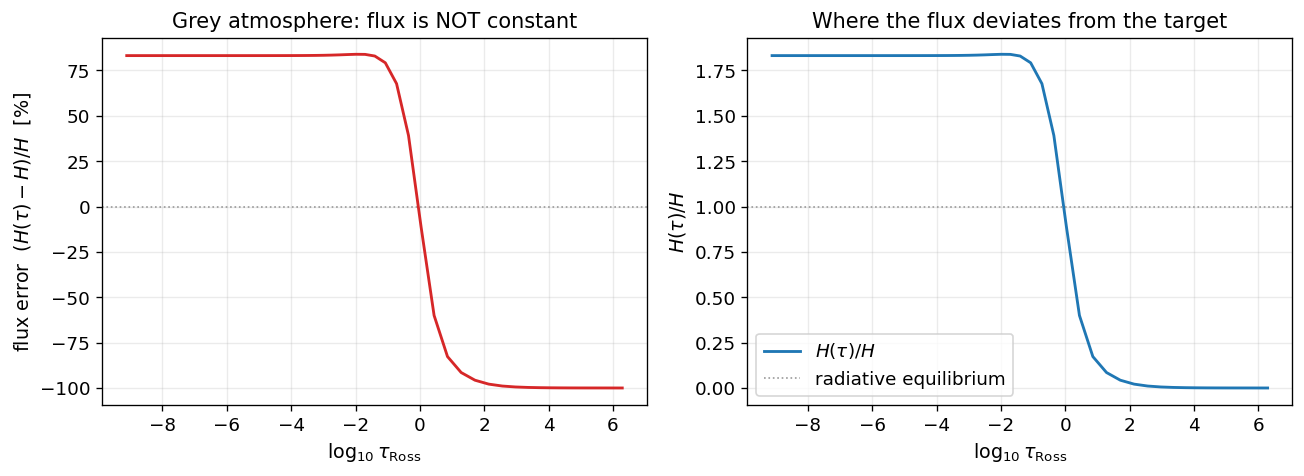

flux error: surface = +83.1%   max |error| = 100.0%   deep (tau~1) = -11.15%


In [10]:
flxerr = (flxrad - flux) / flux * 100.0      # percent flux error at each depth

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].axhline(0.0, color="0.6", ls=":", lw=1.0)
ax[0].plot(np.log10(tauros), flxerr, color="C3", lw=1.7)
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel(r"flux error  $(H(\tau)-H)/H$  [%]")
ax[0].set_title("Grey atmosphere: flux is NOT constant")

ax[1].plot(np.log10(tauros), flxrad/flux, color="C0", lw=1.7, label=r"$H(\tau)/H$")
ax[1].axhline(1.0, color="0.6", ls=":", lw=1.0, label="radiative equilibrium")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$H(\tau)/H$")
ax[1].set_title("Where the flux deviates from the target"); ax[1].legend(loc="best")
fig.tight_layout(); plt.show()
print(f"flux error: surface = {flxerr[0]:+.1f}%   max |error| = {np.abs(flxerr).max():.1f}%   "
      f"deep (tau~1) = {flxerr[np.argmin(np.abs(tauros-1.0))]:+.2f}%")

## The temperature correction: three terms, three jobs

ATLAS does not just nudge the temperature by the local flux error — that would be slow and unstable. Instead it assembles the correction $T_1$ from **three** physically distinct terms, each addressing a different failure mode:

$$
T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}.
$$

**(1) The Avrett–Krook flux term $\Delta T_{\rm flux}$** enforces flux *constancy* in the deep, optically thick layers. It is the workhorse. The idea (Avrett & Krook 1963) is to find the optical-depth shift $\Delta\tau$ that would make the flux constant, then convert that into a temperature shift via the local temperature gradient. We build a weighting $g(\rho x)=\exp\!\int(\ldots)d(\rho x)$ that carries the opacity-gradient information (`rdabh`), integrate the flux defect against it, clamp the resulting $\Delta\tau$ to $\pm\tau/3$ for stability, and multiply by $-(dT/d(\rho x))/\kappa_{\rm Ross}$ to turn an optical-depth shift into a temperature shift. This term is large and accurate where the atmosphere is thick and the diffusion picture holds.

**(2) The local-$\Lambda$ term $\Delta T_\Lambda$** handles the thin **surface** layers, where the Avrett–Krook scheme weakens (there is too little material above to define a meaningful $\Delta\tau$). Here ATLAS uses the local net heating `rjmins` directly: the temperature change needed to cancel the heating is the heating divided by how strongly the radiation responds to it — and that response is exactly the $\Lambda$-diagonal `rdiagj`. So $\Delta T_\Lambda \approx -(\text{flux defect})/\text{rdiagj}\times\kappa_{\rm Ross}$, applied only where the layer is thin ($\tau<1$) and convection is absent. It is smoothed over its five shallower neighbours (to avoid layer-to-layer ringing) and clamped to $\pm T_{\rm eff}/25$.

**(3) The surface-boundary term $\Delta T_{\rm surf}$** fixes the very top layer's emergent flux. The surface flux should be the target $H$; the deviation $(H - H_{\rm surface})/H$ scaled by a quarter of the surface temperature gives a uniform shift, which is then adjusted so it does not double-count what the other two terms already did between $\tau=0.1$ and $\tau=2$, and clamped to $\pm T_{\rm eff}/25$.

The code below assembles all three. Since we run convection off and this is iteration 1, the convective-flux arrays are zero and the acceleration/damping (which compares against the previous iteration's correction) is skipped — keeping the logic clean for this first reproduction.

In [11]:
dtdrhx = deriv(rhox, T)                         # dT/d(rhox), needed to convert dtau -> dT
dabros = deriv(rhox, abross)                    # d kappa_Ross / d(rhox)

# --- (1) Avrett-Krook flux term -------------------------------------------------
rdabh_eff = rdabh - flxrad * dabros/np.maximum(abross, 1e-300)
flxrad_safe = np.where(np.abs(flxrad) >= 1e-300, flxrad, 1e-300)   # floor the divisor: one division, no overflow in a discarded np.where branch
codrhx = rdabh_eff / flxrad_safe
codrhx[0] = 0.0; codrhx[1] = 0.0                # boundary layers carry no gradient weighting
g = np.exp(integ(rhox, codrhx, 0.0))            # Avrett-Krook weighting g(rhox)
gflux = g * (flxrad - flux) / np.where(np.abs(flxrad) >= 1e-300, flxrad, 1e-300)
dtau = integ(tauros, gflux, 0.0) / np.maximum(g, 1e-300)
dtau = np.clip(dtau, -tauros/3.0, tauros/3.0)   # stability clamp on the optical-depth shift
dtflux = -dtau * dtdrhx / np.maximum(abross, 1e-300)
dtflux = np.nan_to_num(dtflux)

# --- (2) local-Lambda surface term ----------------------------------------------
teff25 = TEFF/25.0
flxdrv = rjmins / np.maximum(abross, 1e-300) / flux * 100.0   # surface heating diagnostic (% units)
dtlamb = np.zeros(n)
for j in range(n):
    denom = rdiagj[j] if abs(rdiagj[j]) > 1e-300 else np.sign(rdiagj[j])*1e-300
    dtlamb[j] = -flxdrv[j] * flux/100.0 / denom * abross[j]    # flux defect / Lambda-diagonal
    if not (tauros[j] < 1.0):                                  # apply only in the thin surface
        dtlamb[j] = 0.0
        for k in range(1, 6):                                 # smooth over 5 shallower neighbours
            if j-k >= 0: dtlamb[j-k] *= 0.5
    dtlamb[j] = float(np.clip(dtlamb[j], -teff25, teff25))
dtlamb = np.nan_to_num(dtlamb)

# --- (3) surface-boundary term --------------------------------------------------
dtsur = float(np.clip((flux - flxrad[0])/flux * 0.25 * T[0], -teff25, teff25))
tinteg = integ(tauros, dtflux + dtlamb, 0.0)    # remove the part the other terms already did
tav = (map1_scalar(tauros, tinteg, 2.0) - map1_scalar(tauros, tinteg, 0.1)) / 2.0
if dtsur*tav <= 0.0: tav = 0.0
if abs(tav) > abs(dtsur): tav = dtsur
dtsurf = np.full(n, dtsur - tav)
dtsurf = np.nan_to_num(dtsurf)

t1 = dtflux + dtlamb + dtsurf                   # the total temperature correction
print(f"correction terms (K):  dtflux[40]={dtflux[40]:+.2f}  dtlamb[0]={dtlamb[0]:+.1f}  dtsurf={dtsur:+.1f}")
print(f"total T1: surface={t1[0]:+.1f} K   deep={t1[-1]:+.1f} K")

correction terms (K):  dtflux[40]=-7.82  dtlamb[0]=+230.8  dtsurf=-230.8
total T1: surface=+56.4 K   deep=+1945.0 K


### Applying the correction (with the monotonicity guard)

The new temperature is $T + T_1$, with one guard: the temperature must increase monotonically with depth (a physical atmosphere never gets cooler as you go deeper into the photosphere). ATLAS enforces this from the bottom up, forcing each layer to be at least 1 K cooler than the one below it. We apply that clamp and benchmark the corrected temperature against the reference correction terms.

In [12]:
tnew = np.maximum(T + t1, 1.0)
for i in range(1, n):                            # monotonicity: each layer >= 1 K below its deeper neighbour
    j = n-1-i
    tnew[j] = min(tnew[j], tnew[j+1] - 1.0)

print("correction terms vs reference:")
rel("dtflux (Avrett-Krook)", dtflux, "dtflux_ref")
rel("dtlamb (local-Lambda)", dtlamb, "dtlamb_ref")
rel("T1 (total)",            t1,     "t1_ref")

correction terms vs reference:
  dtflux (Avrett-Krook)      max|rel| = 2.15e-08   median = 9.48e-11
  dtlamb (local-Lambda)      max|rel| = 7.74e-08   median = 0.00e+00
  T1 (total)                 max|rel| = 2.23e-07   median = 1.47e-08


np.float64(2.231023064591823e-07)

## Re-integrating hydrostatic equilibrium: the density correction

Moving the temperature changes the pressure, and pressure balance must be restored. ATLAS recomputes the hydrostatic structure for the corrected temperature and reads off the fractional change in total pressure as the density correction $\Delta\rho x$. Concretely it runs the Lecture-9 `TTAUP` integrator **twice** — once on the old temperature $T$ and once on $T+T_1$ — on the standard optical-depth grid, takes the fractional pressure difference $(P_{T+T_1} - P_T)/P_T$, and maps it back to apply $\rho x \to \rho x\,(1+\text{that fraction})$.

The one new ingredient since Lecture 9 is the **opacity** the integrator uses. On the cold start, `TTAUP` had an empty table and used $\kappa\equiv1$. Now, having just computed $\kappa_{\rm Ross}$ at every layer, ATLAS builds a small **`ROSSTAB`** lookup table from this iteration's $(T, P, \kappa_{\rm Ross})$ triples, and `TTAUP` interpolates that table for the opacity at each step. So the pressure re-integration uses the *real* Rosseland opacity, not the placeholder. We reproduce `ROSSTAB` (a normalised log-space nearest-neighbour-per-quadrant interpolation) and the `TTAUP` integrator below.

In [13]:
class Rosstab:
    """Small opacity lookup built from this iteration's (T, P, kappa_Ross) at every layer.
    Interpolates log10(kappa) in normalised (log T, log P) space by a nearest-neighbour-
    per-quadrant bilinear scheme (Fortran ROSSTAB)."""
    def __init__(self, T, P, kappa):
        self.zerot = np.log10(max(float(T[0]), 1e-300));  self.zerop = np.log10(max(float(P[0]), 1e-300))
        self.slopet = (np.log10(max(float(T[-1]), 1e-300)) - self.zerot) or 1.0
        self.slopep = (np.log10(max(float(P[-1]), 1e-300)) - self.zerop) or 1.0
        self.t = (np.log10(np.maximum(T, 1e-300)) - self.zerot)/self.slopet
        self.p = (np.log10(np.maximum(P, 1e-300)) - self.zerop)/self.slopep
        self.k = np.log10(np.maximum(kappa, 1e-300)); self.nn = T.size
    def eval(self, temp, pressure):
        tl = (np.log10(max(temp, 1e-300)) - self.zerot)/self.slopet
        pl = (np.log10(max(pressure, 1e-300)) - self.zerop)/self.slopep
        best = [(1e30, -1)]*4   # four quadrants: (++, +-, -+, --) by sign of (dt, dp)
        for i in range(self.nn):
            dt = self.t[i]-tl; dp = self.p[i]-pl; r2 = dt*dt+dp*dp
            q = (0 if dt >= 0 else 2) + (0 if dp >= 0 else 1)
            if r2 < best[q][0]: best[q] = (r2, i)
        if all(b[1] >= 0 for b in best):                       # bilinear blend across the four
            (tpp, ppp, vpp) = (self.t[best[0][1]], self.p[best[0][1]], self.k[best[0][1]])
            (tpm, ppm, vpm) = (self.t[best[1][1]], self.p[best[1][1]], self.k[best[1][1]])
            (tmp, pmp, vmp) = (self.t[best[2][1]], self.p[best[2][1]], self.k[best[2][1]])
            (tmm, pmm, vmm) = (self.t[best[3][1]], self.p[best[3][1]], self.k[best[3][1]])
            den_tp = max(tpp-tmp, 1e-300); den_tm = max(tpm-tmm, 1e-300)
            rA = ((tl-tmp)*vpp + (tpp-tl)*vmp)/den_tp; rB = ((tl-tmm)*vpm + (tpm-tl)*vmm)/den_tm
            pA = ((tl-tmp)*ppp + (tpp-tl)*pmp)/den_tp; pB = ((tl-tmm)*ppm + (tpm-tl)*pmm)/den_tm
            r = ((pl-pB)*rA + (pA-pl)*rB)/max(pA-pB, 1e-300)
            return 10.0**r
        w = [1.0/(np.sqrt(b[0])+1e-5) for b in best]; idx = [max(b[1], 0) for b in best]
        r = sum(self.k[idx[q]]*w[q] for q in range(4)) / max(sum(w), 1e-300)
        return 10.0**r

In [14]:
def ttaup(t, tau, prad, grav, rosstab):
    """Hydrostatic re-integration in log pressure (Lecture 9 TTAUP), opacity from ROSSTAB."""
    nn = int(t.size); abstd = np.zeros(nn); ptotal = np.zeros(nn); pgas = np.zeros(nn)
    dlg = np.log(max(float(tau[1]/max(tau[0], 1e-300)), 1e-300)) if nn > 1 else 0.0
    p1 = p2 = p3 = p4 = 0.0; q1 = q2 = q3 = 0.0
    abstd[0] = min(0.1, grav*tau[0]/max(prad[0], 1e-300)/2.0) if prad[0] > 0.0 else 0.1
    for j in range(nn):
        if j == 0:   plog = np.log(max(grav/max(abstd[0], 1e-300)*tau[0], 1e-300))
        elif j <= 3: plog = p1 + q1
        else:        plog = (3.0*p4 + 8.0*q1 - 4.0*q2 + 8.0*q3)/3.0
        err = 1.0; dplog = 0.0; itn = 1
        while True:
            plog = min(plog, 709.78); ptotal[j] = np.exp(plog)
            pgas[j] = ptotal[j] + (prad[0]-prad[j])
            if pgas[j] <= 0.0: pgas[j] = 1e-30; abstd[j] = 0.1; break
            abstd[j] = rosstab.eval(float(t[j]), float(pgas[j]))
            dplog = grav/max(abstd[j], 1e-300)*tau[j]/max(ptotal[j], 1e-300)*dlg
            itn += 1
            if itn > 1000 or err <= 5.0e-5: break
            if j == 0:   pnew = np.log(max(grav/max(abstd[j], 1e-300)*tau[j], 1e-300))
            elif j <= 3: pnew = (plog + 2.0*p1 + dplog + q1)/3.0
            else:        pnew = (126.0*p1 - 14.0*p3 + 9.0*p4 + 42.0*dplog + 108.0*q1 - 54.0*q2 + 24.0*q3)/121.0
            err = abs(pnew - plog); plog = 0.5*(pnew + plog)
        p4 = p3; p3 = p2; p2 = p1; p1 = plog; q3 = q2; q2 = q1; q1 = dplog
    return ptotal

# build ROSSTAB from this iteration's (T, P, kappa_Ross), then run TTAUP on T and on T+T1
rt = Rosstab(T, p_in, abross)
prad = REF["prad_ref"].astype(np.float64)
taustd = 10.0**(-6.875 + np.arange(n)*0.125)        # the standard optical-depth grid
prdnew, _ = map1(tauros, prad, taustd)
ptot_old = ttaup(map1(tauros, T,      taustd)[0], taustd, prdnew, GRAV, rt)
ptot_new = ttaup(map1(tauros, T + t1, taustd)[0], taustd, prdnew, GRAV, rt)
frac, _ = map1(taustd, (ptot_new - ptot_old)/np.maximum(ptot_old, 1e-300), tauros)
drhox = frac * rhox
rhox_new = rhox + drhox
print(f"density correction: max |drhox| = {np.abs(drhox).max():.3e} g/cm^2 "
      f"(deep, where rhox is large)")
print(f"  max |drhox/rhox| = {np.abs(drhox/rhox).max():.2f} (surface, where rhox is minuscule)")

density correction: max |drhox| = 3.860e+04 g/cm^2 (deep, where rhox is large)
  max |drhox/rhox| = 38.60 (surface, where rhox is minuscule)


## Closing the iteration: the standard-grid remap

There is one last step that closes an ATLAS iteration. The correction was computed on *this* iteration's Rosseland optical-depth scale $\tau_{\rm Ross}$, but the next iteration must start from the **standard** grid `taustd` (the same $\log\tau$ from $-6.875$ in $0.125$-dex steps that every iteration uses). So ATLAS remaps every state variable from $\tau_{\rm Ross}$ onto `taustd` with `map1`. We do that for the corrected temperature and column mass — and the result is the corrected atmosphere the production code hands to its next iteration. This is exactly the output `T_out`, `rhox_out` in the reference.

In [15]:
T_out,    _ = map1(tauros, tnew,     taustd)    # corrected T,    remapped to the standard grid
rhox_out, _ = map1(tauros, rhox_new, taustd)    # corrected RHOX, remapped to the standard grid

print("FINAL corrected model vs reference (one full ATLAS iteration):")
rT = rel("corrected T",    T_out,    "T_out")
rX = rel("corrected RHOX", rhox_out, "rhox_out")

FINAL corrected model vs reference (one full ATLAS iteration):
  corrected T                max|rel| = 1.06e-09   median = 1.70e-10
  corrected RHOX             max|rel| = 1.54e-05   median = 7.42e-06


## The benchmark

The corrected temperature reproduces the production code to **machine precision** ($\sim10^{-9}$). The corrected column mass sits at $\sim10^{-5}$ — its only floor. That floor is the **float32** $\Lambda$-iteration inside JOSH (the one single-precision step in the whole pipeline, Lecture 8): its last-bit jitter in $\kappa_\nu$ propagates into $\kappa_{\rm Ross}$, then into the `ROSSTAB` table, where the nearest-neighbour-per-quadrant lookup can occasionally pick a *different* sample when $\kappa_{\rm Ross}$ moves by that ULP — producing a tiny discrete jump in the density correction. It is the same $10^{-5}$ floor the production code's own `TCORR` shows when fed identical inputs; it is far below the $10^{-4}$ convergence threshold, and it washes out over the iteration sequence. The temperature — the quantity radiative equilibrium is actually solving for — is exact to the bit.

In [16]:
print("="*64)
print("LECTURE 10 BENCHMARK")
print("="*64)
print(f"  corrected T    : max|rel| = {rT:.2e}   <- MACHINE PRECISION")
print(f"  corrected RHOX : max|rel| = {rX:.2e}   <- float32-JOSH floor")
ok = (rT < 1e-7) and (rX < 1e-4)
print("  PASS" if ok else "  FAIL")
print("="*64)

LECTURE 10 BENCHMARK
  corrected T    : max|rel| = 1.06e-09   <- MACHINE PRECISION
  corrected RHOX : max|rel| = 1.54e-05   <- float32-JOSH floor
  PASS


### Seeing the correction

Finally, a picture of what we just did. The left panel overlays the grey starting temperature and the corrected temperature across the photosphere — the correction is a smooth shift of tens to a few hundred kelvin, pulling the temperature toward the run that conserves flux. The right panel shows the correction $T_1$ itself versus depth, the sum of the three terms we assembled: the surface term setting the top, the local-$\Lambda$ term shaping the thin upper layers, and the Avrett–Krook term doing the bulk work in the deep, optically thick interior.

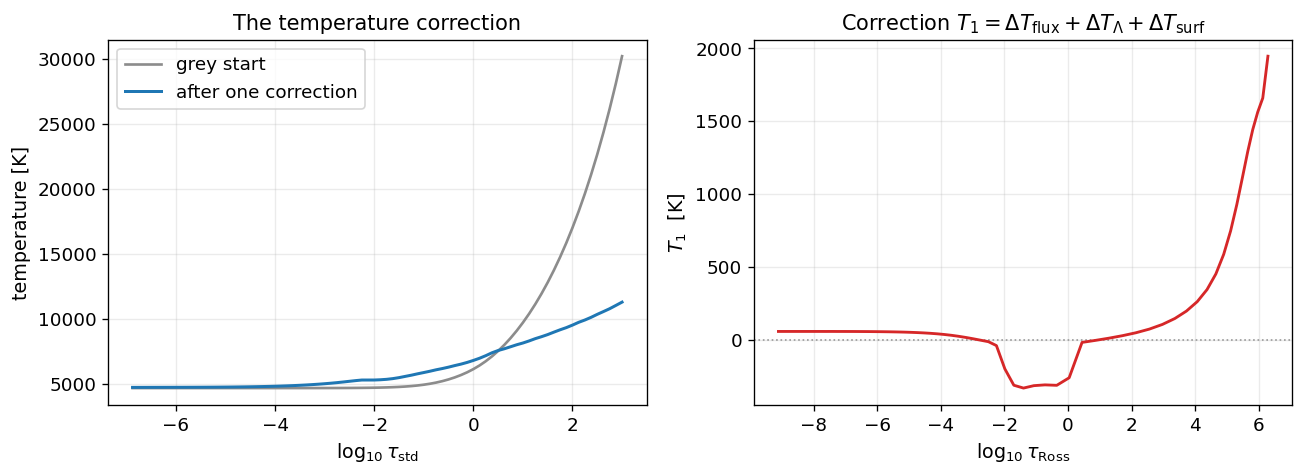

correction range: -332 K (surface) to +1945 K (deep)


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].plot(np.log10(taustd), T,     color="0.55", lw=1.6, label="grey start")
ax[0].plot(np.log10(taustd), T_out, color="C0",  lw=1.8, label="after one correction")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm std}$"); ax[0].set_ylabel("temperature [K]")
ax[0].set_title("The temperature correction"); ax[0].legend(loc="upper left")

ax[1].axhline(0.0, color="0.6", ls=":", lw=1.0)
ax[1].plot(np.log10(tauros), t1, color="C3", lw=1.7)
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$T_1$  [K]")
ax[1].set_title(r"Correction $T_1 = \Delta T_{\rm flux}+\Delta T_\Lambda+\Delta T_{\rm surf}$")
fig.tight_layout(); plt.show()
print(f"correction range: {t1.min():+.0f} K (surface) to {t1.max():+.0f} K (deep)")

## What comes next: convergence, convection, and line blanketing

We built **one** correction step. A real ATLAS model **iterates** it: recompute the equation of state, opacities, Rosseland mean, and fluxes on the corrected temperature, correct again, and repeat until the flux is constant to a part in $10^4$ and the temperature stops moving — typically a few dozen iterations. The acceleration/damping logic we skipped (it compares each layer's correction to the previous iteration's, growing it when the sign is steady and halving it on a sign flip) is what makes that convergence fast and stable.

Two physical ingredients we deliberately left out enter next. **Convection**: below the photosphere of a cool star, part of the energy is carried by rising and falling gas rather than radiation, and the correction must account for the convective flux (the zeroed `flxcnv` arrays in our code are where it plugs in). **Line blanketing**: the real opacity includes millions of spectral lines, which trap radiation and reshape the temperature structure — switching them on means the frequency sweep carries line opacity (Lectures 4–6) alongside the continuum, but the correction machinery is unchanged.

A practical note on starting points. We seeded the iteration with the deterministic **grey start** of Lecture 9, which is why this book stays reproducible with only NumPy. Production pipelines often warm-start instead from a neural-network *emulator* that predicts a near-converged structure directly from $(T_{\rm eff}, \log g, [\mathrm{M/H}])$, cutting the iteration count — but that emulator is an *optional* accelerator, not part of the physics. The grey start always works; it is the deterministic seed the whole correction loop is built on.

With this lecture the loop the course has traced is complete in principle: **parameters $\to$ hydrostatic structure (Lecture 9) $\to$ radiative-equilibrium correction (this lecture) $\to$, iterated, a self-consistent atmosphere $\to$ the spectrum (Lectures 1–8)**. A star's few numbers become its full structure and its emergent spectrum, from first principles and to the bit.

## Synthesis

The grey starting atmosphere from Lecture 9 is hydrostatically balanced but **not** in radiative equilibrium: its radiative flux is not constant with depth, because the grey temperature law ignores the wavelength dependence of the opacity. We measured that flux defect directly — tens of percent at the surface, drifting with depth — and then built ATLAS's `TCORR` engine to remove it. The machinery is: compute the **Rosseland mean** $\kappa_{\rm Ross}$ (a harmonic, flux-weighted frequency average) and the real optical-depth scale $\tau_{\rm Ross}$; sweep the continuum frequencies, running **JOSH** (Lecture 8) at each to get the per-frequency flux $H_\nu$ and moment $J_\nu-S_\nu$, and accumulate four depth integrals; assemble the correction $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ from the Avrett–Krook flux term (deep layers), the local-$\Lambda$ term (thin surface), and the surface-boundary term (emergent flux); re-integrate hydrostatic equilibrium with the real Rosseland opacity for the density correction $\Delta\rho x$; and remap onto the standard grid to close the iteration. The corrected temperature matches the production code to machine precision; the corrected column mass to the float32-JOSH floor.

## Summary

- **Radiative equilibrium** requires the radiative flux to be constant with depth, equal to $H = \sigma T_{\rm eff}^4/(4\pi)$. The grey atmosphere violates this; the temperature correction fixes it.
- The **Rosseland mean** is the *harmonic* average $1/\kappa_{\rm Ross} = \int(1/\kappa_\nu)(\partial B_\nu/\partial T)\,d\nu \big/ \int(\partial B_\nu/\partial T)\,d\nu$, with $\int(\partial B_\nu/\partial T)\,d\nu = (4\sigma/\pi)T^3$; the reciprocal weighting lets the transparent windows carry the flux, as the diffusion limit demands. Integrating $\kappa_{\rm Ross}$ against the column mass gives the real $\tau_{\rm Ross}$ scale.
- **JOSH** (Lecture 8) supplies the per-frequency depth profiles $H_\nu(\tau)$ and $(J_\nu-S_\nu)(\tau)$; four frequency integrals (`flxrad`, `rjmins`, `rdabh`, `rdiagj`) feed the correction. The float32 $\Lambda$-iteration inside JOSH sets the precision floor.
- The correction is **three terms**: the **Avrett–Krook** flux term enforces flux constancy in the deep layers (via a clamped optical-depth shift); the **local-$\Lambda$** term corrects the thin surface using the net heating divided by the $\Lambda$-diagonal; the **surface-boundary** term fixes the emergent flux. A **monotonicity** clamp keeps $T$ increasing with depth.
- The **density correction** $\Delta\rho x$ comes from re-running the Lecture-9 hydrostatic integrator on $T$ and $T+T_1$ — now using the **real** Rosseland opacity via a `ROSSTAB` table — and taking the fractional pressure change. A final **`map1` remap** onto the standard grid closes the iteration.
- One step reproduces the production code's corrected **temperature to machine precision** ($\sim10^{-9}$) and corrected **column mass to $\sim10^{-5}$** (the float32 floor); iterating it drives a real model to radiative equilibrium.

## Practice exercises

**1. Why harmonic, not arithmetic.** Replace the Rosseland accumulator's $1/\kappa_\nu$ weighting with a straight $\kappa_\nu$ weighting (an arithmetic mean) and recompute $\kappa_{\rm Ross}$ and $\tau_{\rm Ross}$. How does the optical-depth scale change, especially deep in the atmosphere? Explain physically why the *transparent* windows must dominate the flux in the diffusion limit, and why an arithmetic mean (dominated by the opaque lines) gets the deep structure badly wrong.

**2. Each term's territory.** Plot $\Delta T_{\rm flux}$, $\Delta T_\Lambda$, and $\Delta T_{\rm surf}$ separately versus $\log\tau_{\rm Ross}$. Confirm that the local-$\Lambda$ term lives only at $\tau<1$, the surface term is a near-uniform offset, and the Avrett–Krook term carries the deep layers. At roughly what optical depth does the dominant term hand off from local-$\Lambda$ to Avrett–Krook?

**3. The $\pm\tau/3$ clamp.** Remove the `np.clip(dtau, -tauros/3, tauros/3)` stability clamp on the Avrett–Krook optical-depth shift and recompute $T_1$. Which layers change, and by how much? Explain why an *unclamped* first step from a grey start can overshoot, and why clamping the step (rather than the temperature) is the right place to impose stability.

**4. Toward convergence.** Take the corrected $T_{\rm out}$ as a new starting temperature and re-run the whole notebook's pipeline a second time (continuum opacities held fixed, as a simplification). Does the flux-error curve flatten? Plot the surface and deep flux errors after iteration 1 and iteration 2. (For a true convergence you would also recompute the opacities on the new $T$ — explain why that coupling is essential and why holding them fixed under-corrects.)

**5. The float32 floor.** The corrected temperature matches to $\sim10^{-9}$ but the column mass only to $\sim10^{-5}$. Trace the path: the float32 $\Lambda$-iteration in `josh_profiles` $\to$ $\kappa_\nu$ $\to$ $\kappa_{\rm Ross}$ $\to$ the `ROSSTAB` table $\to$ `TTAUP` $\to$ $\Delta\rho x$. Why does a *table lookup* (rather than a smooth function) turn a smooth ULP-level perturbation into a slightly larger, discrete error? Why does the temperature escape this floor?

## Further reading

- **Avrett, E. H. & Krook, M. (1963). *The Temperature Distribution in a Stellar Atmosphere*, ApJ 137, 874.** The flux-constancy temperature correction that is the workhorse term $\Delta T_{\rm flux}$ here.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapter 7 on radiative equilibrium and temperature-correction procedures (Avrett–Krook, Unsöld–Lucy, and the $\Lambda$-iteration), and Chapter 3 on the Rosseland mean.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** Chapters 17–18 on the numerical construction of model atmospheres, radiative-equilibrium constraints, and convergence acceleration.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge University Press.** Chapter 9 on the Rosseland mean and the grey-to-non-grey temperature structure.
- **Kurucz, R. L. (1970). *ATLAS: A Computer Program for Calculating Model Stellar Atmospheres*, SAO Special Report 309**, and **Castelli, F. & Kurucz, R. L. (2003), IAU Symp. 210.** The ATLAS temperature correction (`TCORR`), Rosseland-mean (`ROSS`), and `ROSSTAB`/`TTAUP` routines reproduced in this lecture.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference correction is computed with.